# Big Data Pipeline: U.S. Border Crossing Analysis with Apache Spark and MongoDB

### Team Contributions

The project was completed through a structured division of responsibilities, ensuring both efficiency and consistency across all stages of the pipeline.

- **Muhamed Aniss Lotfy** was responsible for data preprocessing and initial exploration (Sections 1–3), as well as the analysis of seasonal patterns in border crossings (Section 9.2).

- **Jie Xu** focused on data transformation and Spark-based processing (Sections 4–5), and conducted the analysis of external factors, particularly the impact of COVID-19 on border crossings (Section 9.3).

- **Mu Zhao** handled database integration and querying (Sections 6–7), and performed advanced analysis on port growth and decline trends (Section 9.4).

- **Weiwei Zhang** was responsible for overall system design and integration, performance comparison and optimization (Section 8), long-term structural analysis (Section 9.1), and the implementation of bonus tasks. Additionally, the project lead ensured consistency across all sections and coordinated the final structure of the report.

## 1. Environment Setup

This section initializes the required environment, including Apache Spark, MongoDB connection, and necessary Python libraries.

In [ ]:
# Initialize Spark
from pyspark.sql import SparkSession
import pyspark.sql.functions as F

spark = SparkSession.builder \
    .appName("BorderCrossingAnalysis") \
    .getOrCreate()

print("Spark is working!")

Spark is working!


In [ ]:
from pymongo import MongoClient

client = MongoClient("mongodb://localhost:27017/")
db = client["border_crossing_db"]

print("MongoDB connected!")

MongoDB connected!


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries loaded!")

Libraries loaded!


## 2. Data Loading and Initial Inspection

In this section, we load the dataset and perform initial inspection to understand its structure, size, and key attributes.

In [ ]:
df = spark.read.csv("Border_Crossing_Entry_Data.csv", header=True, inferSchema=True)

print("Data loaded successfully!")

Data loaded successfully!


In [ ]:
# Preview the data
df.show(5)

+-----------+---------+---------+----------------+--------+-------+-----+--------+---------+--------------------+
|  Port Name|    State|Port Code|          Border|    Date|Measure|Value|Latitude|Longitude|               Point|
+-----------+---------+---------+----------------+--------+-------+-----+--------+---------+--------------------+
|    Hidalgo|    Texas|     2305|US-Mexico Border|Jan 2026|  Buses|  640|  26.095|  -98.271|POINT (-98.271092...|
|Brownsville|    Texas|     2301|US-Mexico Border|Jan 2026|  Buses|  264|  25.952|  -97.401|POINT (-97.40067 ...|
|    Warroad|Minnesota|     3423|US-Canada Border|Dec 2025|  Buses|    9|  48.999|  -95.377|POINT (-95.376555...|
|      Alcan|   Alaska|     3104|US-Canada Border|Nov 2025| Trucks|  547|  62.615| -141.001|POINT (-141.00144...|
|     Laredo|    Texas|     2304|US-Mexico Border|Jul 2025|  Buses| 2546|    27.5|  -99.507|POINT (-99.507412...|
+-----------+---------+---------+----------------+--------+-------+-----+--------+------

In [ ]:
# Dataset structure
df.printSchema()

root
 |-- Port Name: string (nullable = true)
 |-- State: string (nullable = true)
 |-- Port Code: integer (nullable = true)
 |-- Border: string (nullable = true)
 |-- Date: string (nullable = true)
 |-- Measure: string (nullable = true)
 |-- Value: integer (nullable = true)
 |-- Latitude: double (nullable = true)
 |-- Longitude: double (nullable = true)
 |-- Point: string (nullable = true)



In [ ]:
rows = df.count()
cols = len(df.columns)

print(f"Total rows: {rows}")
print(f"Total columns: {cols}")

Total rows: 273391
Total columns: 10


In [ ]:
print("Column names:")
for col_name in df.columns:
    print(col_name)

Column names:
Port Name
State
Port Code
Border
Date
Measure
Value
Latitude
Longitude
Point


In [ ]:
# Statistical summary
df.describe().show()

+-------+---------+----------+------------------+----------------+--------+--------------+------------------+-----------------+------------------+--------------------+
|summary|Port Name|     State|         Port Code|          Border|    Date|       Measure|             Value|         Latitude|         Longitude|               Point|
+-------+---------+----------+------------------+----------------+--------+--------------+------------------+-----------------+------------------+--------------------+
|  count|   273391|    273387|            273391|          273391|  273391|        273391|            273391|           273387|            273387|              273387|
|   mean|     NULL|      NULL|  2447.97364946176|            NULL|    NULL|          NULL| 41979.96001697203|43.90901211469556|-99.81721089518047|                NULL|
| stddev|     NULL|      NULL|1199.7471110625079|            NULL|    NULL|          NULL|180977.99503700214|8.183531831499518| 18.23658657198982|              

In [ ]:
from pyspark.sql.functions import col, when, count

df.select([
    count(when(col(c).isNull(), c)).alias(c) for c in df.columns
]).show()

+---------+-----+---------+------+----+-------+-----+--------+---------+-----+
|Port Name|State|Port Code|Border|Date|Measure|Value|Latitude|Longitude|Point|
+---------+-----+---------+------+----+-------+-----+--------+---------+-----+
|        0|    4|        0|     0|   0|      0|    0|       4|        4|    4|
+---------+-----+---------+------+----+-------+-----+--------+---------+-----+



## 3. Data Cleaning and Feature Engineering

This section prepares the dataset for analysis by handling missing values, selecting relevant columns, and extracting useful features such as year and month from the date field.

In [ ]:
# Select relevant columns
df_clean = df.select(
    "Port Name",
    "State",
    "Border",
    "Date",
    "Measure",
    "Value"
)

df_clean.select("Date").show(5, False)

+--------+
|Date    |
+--------+
|Jan 2026|
|Jan 2026|
|Dec 2025|
|Nov 2025|
|Jul 2025|
+--------+
only showing top 5 rows


In [ ]:
# Handle missing values
df_clean = df_clean.dropna(subset=["Value"])

In [ ]:


df_clean = df_clean.withColumn(
    "Date",
    F.to_date(
        F.concat(F.lit("01 "), F.trim(F.col("Date"))),
        "dd MMM yyyy"
    )
)

df_clean.select("Date").show(5, False)

+----------+
|Date      |
+----------+
|2026-01-01|
|2026-01-01|
|2025-12-01|
|2025-11-01|
|2025-07-01|
+----------+
only showing top 5 rows


In [ ]:
df_clean = df_clean.withColumn("Year", F.year(F.col("Date")))
df_clean = df_clean.withColumn("Month", F.month(F.col("Date")))

df_clean.select("Date", "Year", "Month").show(5)

+----------+----+-----+
|      Date|Year|Month|
+----------+----+-----+
|2026-01-01|2026|    1|
|2026-01-01|2026|    1|
|2025-12-01|2025|   12|
|2025-11-01|2025|   11|
|2025-07-01|2025|    7|
+----------+----+-----+
only showing top 5 rows


In [ ]:
# Preview cleaned data
df_clean.show(10)

+--------------------+---------+----------------+----------+--------------------+-----+----+-----+
|           Port Name|    State|          Border|      Date|             Measure|Value|Year|Month|
+--------------------+---------+----------------+----------+--------------------+-----+----+-----+
|             Hidalgo|    Texas|US-Mexico Border|2026-01-01|               Buses|  640|2026|    1|
|         Brownsville|    Texas|US-Mexico Border|2026-01-01|               Buses|  264|2026|    1|
|             Warroad|Minnesota|US-Canada Border|2025-12-01|               Buses|    9|2025|   12|
|               Alcan|   Alaska|US-Canada Border|2025-11-01|              Trucks|  547|2025|   11|
|              Laredo|    Texas|US-Mexico Border|2025-07-01|               Buses| 2546|2025|    7|
|                Roma|    Texas|US-Mexico Border|2025-07-01|               Buses|   67|2025|    7|
|Chief Mountain Mt...|     NULL|US-Canada Border|2025-07-01|   Personal Vehicles| 6082|2025|    7|
|Chief Mou

## 4. MongoDB Storage and Schema Design

The cleaned dataset is stored in MongoDB as a collection of documents.  
Each document represents one border crossing record.

The main attributes include:

- Port Name
- State
- Border
- Date
- Measure
- Value
- MongoDB Sharding Demonstration

MongoDB is suitable because it supports flexible document-based storage, allowing efficient querying and aggregation.

Indexes are created on key fields such as Border, Measure, and Date to improve query performance.

Although the current dataset size is moderate, sharding was demonstrated to show how the MongoDB layer could scale for larger cross-border datasets and distributed query workloads.

In [ ]:
from pymongo import MongoClient

client = MongoClient("mongodb://localhost:27120/")
db = client["crossborder_db"]
collection = db["crossings"]

print("Connected to sharded MongoDB cluster through mongos")

Connected to sharded MongoDB cluster through mongos


In [ ]:
import pandas as pd
import numpy as np
import datetime
import time

# Start timing
start_time = time.time()

# Convert Spark DataFrame to Pandas
mongo_df = df.toPandas().copy()

# Clean records for MongoDB
records = []
for row in mongo_df.to_dict("records"):
    clean_row = {}
    for k, v in row.items():
        if isinstance(v, datetime.date):
            clean_row[k] = str(v)
        elif isinstance(v, np.integer):
            clean_row[k] = int(v)
        elif isinstance(v, np.floating):
            clean_row[k] = float(v)
        elif pd.isna(v):
            clean_row[k] = None
        else:
            clean_row[k] = v
    records.append(clean_row)

print(f"Prepared {len(records)} records for MongoDB insertion.")

# Clear old data
collection.delete_many({})
print("Old documents deleted.")

# Insert in batches
batch_size = 10000
for i in range(0, len(records), batch_size):
    batch = records[i:i + batch_size]
    collection.insert_many(batch)
    print(f"Inserted {i + len(batch)} / {len(records)}")

# End timing
end_time = time.time()
total_time = round(end_time - start_time, 2)

print("Inserted documents:", collection.count_documents({}))
print("Total insertion time:", total_time, "seconds")

Prepared 273391 records for MongoDB insertion.
Old documents deleted.
Inserted 10000 / 273391
Inserted 20000 / 273391
Inserted 30000 / 273391
Inserted 40000 / 273391
Inserted 50000 / 273391
Inserted 60000 / 273391
Inserted 70000 / 273391
Inserted 80000 / 273391
Inserted 90000 / 273391
Inserted 100000 / 273391
Inserted 110000 / 273391
Inserted 120000 / 273391
Inserted 130000 / 273391
Inserted 140000 / 273391
Inserted 150000 / 273391
Inserted 160000 / 273391
Inserted 170000 / 273391
Inserted 180000 / 273391
Inserted 190000 / 273391
Inserted 200000 / 273391
Inserted 210000 / 273391
Inserted 220000 / 273391
Inserted 230000 / 273391
Inserted 240000 / 273391
Inserted 250000 / 273391
Inserted 260000 / 273391
Inserted 270000 / 273391
Inserted 273391 / 273391
Inserted documents: 273391
Total insertion time: 1248.07 seconds


![Sharding result](shards.png)

MongoDB stores the dataset in a document-oriented format and improves query efficiency through indexing on key attributes such as Border, Measure, and Date.

In [ ]:
# Query 1
list(collection.find({"Border": "US-Canada Border"}).limit(3))

[{'_id': ObjectId('69dffe75b5117f6002158043'),
  'Port Name': 'Warroad',
  'State': 'Minnesota',
  'Port Code': 3423,
  'Border': 'US-Canada Border',
  'Date': 'Dec 2025',
  'Measure': 'Buses',
  'Value': 9,
  'Latitude': 48.999,
  'Longitude': -95.377,
  'Point': 'POINT (-95.376555 48.999)'},
 {'_id': ObjectId('69dffe75b5117f6002158044'),
  'Port Name': 'Alcan',
  'State': 'Alaska',
  'Port Code': 3104,
  'Border': 'US-Canada Border',
  'Date': 'Nov 2025',
  'Measure': 'Trucks',
  'Value': 547,
  'Latitude': 62.615,
  'Longitude': -141.001,
  'Point': 'POINT (-141.001444 62.614961)'},
 {'_id': ObjectId('69dffe75b5117f6002158049'),
  'Port Name': 'Calais',
  'State': 'Maine',
  'Port Code': 115,
  'Border': 'US-Canada Border',
  'Date': 'Apr 2025',
  'Measure': 'Bus Passengers',
  'Value': 318,
  'Latitude': 45.189,
  'Longitude': -67.275,
  'Point': 'POINT (-67.275381 45.188548)'}]

In [ ]:
# Query 2
list(collection.find({"Measure": "Personal Vehicles"}).limit(3))

[{'_id': ObjectId('69dffe75b5117f6002158047'),
  'Port Name': 'Chief Mountain Mt Poe',
  'State': None,
  'Port Code': 3315,
  'Border': 'US-Canada Border',
  'Date': 'Jul 2025',
  'Measure': 'Personal Vehicles',
  'Value': 6082,
  'Latitude': None,
  'Longitude': None,
  'Point': None},
 {'_id': ObjectId('69dffe75b5117f6002158163'),
  'Port Name': 'Morgan',
  'State': 'Montana',
  'Port Code': 3319,
  'Border': 'US-Canada Border',
  'Date': 'Oct 2002',
  'Measure': 'Personal Vehicles',
  'Value': 388,
  'Latitude': 49.0,
  'Longitude': -107.832,
  'Point': 'POINT (-107.831819 48.999829)'},
 {'_id': ObjectId('69dffe75b5117f60021581c7'),
  'Port Name': 'Skagway',
  'State': 'Alaska',
  'Port Code': 3103,
  'Border': 'US-Canada Border',
  'Date': 'Jan 1997',
  'Measure': 'Personal Vehicles',
  'Value': 340,
  'Latitude': 59.63,
  'Longitude': -135.164,
  'Point': 'POINT (-135.164444 59.629722)'}]

In [ ]:
# Query 3
list(collection.find({
    "Border": "US-Mexico Border",
    "Measure": "Trucks"
}).limit(3))

[{'_id': ObjectId('69dffe75b5117f6002158072'),
  'Port Name': 'Nogales',
  'State': 'Arizona',
  'Port Code': 2604,
  'Border': 'US-Mexico Border',
  'Date': 'Mar 2021',
  'Measure': 'Trucks',
  'Value': 39374,
  'Latitude': 31.333,
  'Longitude': -110.943,
  'Point': 'POINT (-110.942516 31.332839)'},
 {'_id': ObjectId('69dffe75b5117f600215807b'),
  'Port Name': 'Roma',
  'State': 'Texas',
  'Port Code': 2310,
  'Border': 'US-Mexico Border',
  'Date': 'Jan 2020',
  'Measure': 'Trucks',
  'Value': 1499,
  'Latitude': 26.404,
  'Longitude': -99.019,
  'Point': 'POINT (-99.018981 26.403928)'},
 {'_id': ObjectId('69dffe75b5117f600215808f'),
  'Port Name': 'Roma',
  'State': 'Texas',
  'Port Code': 2310,
  'Border': 'US-Mexico Border',
  'Date': 'Jan 2018',
  'Measure': 'Trucks',
  'Value': 609,
  'Latitude': 26.404,
  'Longitude': -99.019,
  'Point': 'POINT (-99.018981 26.403928)'}]

In [ ]:
print("Inserted:", collection.count_documents({}))

Inserted: 273391


In [ ]:
print("Sample records:")
for doc in collection.find().limit(3):
    print(doc)

Sample records:
{'_id': ObjectId('69dffe75b5117f6002158041'), 'Port Name': 'Hidalgo', 'State': 'Texas', 'Port Code': 2305, 'Border': 'US-Mexico Border', 'Date': 'Jan 2026', 'Measure': 'Buses', 'Value': 640, 'Latitude': 26.095, 'Longitude': -98.271, 'Point': 'POINT (-98.271092 26.095032)'}
{'_id': ObjectId('69dffe75b5117f6002158042'), 'Port Name': 'Brownsville', 'State': 'Texas', 'Port Code': 2301, 'Border': 'US-Mexico Border', 'Date': 'Jan 2026', 'Measure': 'Buses', 'Value': 264, 'Latitude': 25.952, 'Longitude': -97.401, 'Point': 'POINT (-97.40067 25.95155)'}
{'_id': ObjectId('69dffe75b5117f6002158045'), 'Port Name': 'Laredo', 'State': 'Texas', 'Port Code': 2304, 'Border': 'US-Mexico Border', 'Date': 'Jul 2025', 'Measure': 'Buses', 'Value': 2546, 'Latitude': 27.5, 'Longitude': -99.507, 'Point': 'POINT (-99.507412 27.499561)'}


In [ ]:
print("Query test:")
for doc in collection.find({"Border": "US-Canada Border"}).limit(3):
    print(doc)

Query test:
{'_id': ObjectId('69dffe75b5117f6002158043'), 'Port Name': 'Warroad', 'State': 'Minnesota', 'Port Code': 3423, 'Border': 'US-Canada Border', 'Date': 'Dec 2025', 'Measure': 'Buses', 'Value': 9, 'Latitude': 48.999, 'Longitude': -95.377, 'Point': 'POINT (-95.376555 48.999)'}
{'_id': ObjectId('69dffe75b5117f6002158044'), 'Port Name': 'Alcan', 'State': 'Alaska', 'Port Code': 3104, 'Border': 'US-Canada Border', 'Date': 'Nov 2025', 'Measure': 'Trucks', 'Value': 547, 'Latitude': 62.615, 'Longitude': -141.001, 'Point': 'POINT (-141.001444 62.614961)'}
{'_id': ObjectId('69dffe75b5117f6002158049'), 'Port Name': 'Calais', 'State': 'Maine', 'Port Code': 115, 'Border': 'US-Canada Border', 'Date': 'Apr 2025', 'Measure': 'Bus Passengers', 'Value': 318, 'Latitude': 45.189, 'Longitude': -67.275, 'Point': 'POINT (-67.275381 45.188548)'}


#MongoDB Sharding Demonstration


## 5. Exploratory Analysis with PySpark DataFrame API

This section performs initial exploratory data analysis using PySpark DataFrame API to understand overall patterns in the dataset.

### 5.1 Total Crossings by Border

This analysis compares the total number of crossings between the U.S.-Canada and U.S.-Mexico borders.

In [ ]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("CrossBorderEDA") \
    .getOrCreate()

In [ ]:
df = spark.read.csv("Border_Crossing_Entry_Data.csv", header=True, inferSchema=True)

In [ ]:
df.show(5)
df.printSchema()

+-----------+---------+---------+----------------+--------+-------+-----+--------+---------+--------------------+
|  Port Name|    State|Port Code|          Border|    Date|Measure|Value|Latitude|Longitude|               Point|
+-----------+---------+---------+----------------+--------+-------+-----+--------+---------+--------------------+
|    Hidalgo|    Texas|     2305|US-Mexico Border|Jan 2026|  Buses|  640|  26.095|  -98.271|POINT (-98.271092...|
|Brownsville|    Texas|     2301|US-Mexico Border|Jan 2026|  Buses|  264|  25.952|  -97.401|POINT (-97.40067 ...|
|    Warroad|Minnesota|     3423|US-Canada Border|Dec 2025|  Buses|    9|  48.999|  -95.377|POINT (-95.376555...|
|      Alcan|   Alaska|     3104|US-Canada Border|Nov 2025| Trucks|  547|  62.615| -141.001|POINT (-141.00144...|
|     Laredo|    Texas|     2304|US-Mexico Border|Jul 2025|  Buses| 2546|    27.5|  -99.507|POINT (-99.507412...|
+-----------+---------+---------+----------------+--------+-------+-----+--------+------

In [ ]:
from pyspark.sql.functions import sum

border_analysis = df.groupBy("Border") \
    .agg(sum("Value").alias("Total_Crossings")) \
    .orderBy("Total_Crossings", ascending=False)

border_analysis.show()

+----------------+---------------+
|          Border|Total_Crossings|
+----------------+---------------+
|US-Mexico Border|     8596716289|
|US-Canada Border|     2880226960|
+----------------+---------------+



In [ ]:
df.createOrReplaceTempView("crossings")

spark.sql("""
SELECT Border, SUM(Value) AS Total_Crossings
FROM crossings
GROUP BY Border
ORDER BY Total_Crossings DESC
""").show()

+----------------+---------------+
|          Border|Total_Crossings|
+----------------+---------------+
|US-Mexico Border|     8596716289|
|US-Canada Border|     2880226960|
+----------------+---------------+



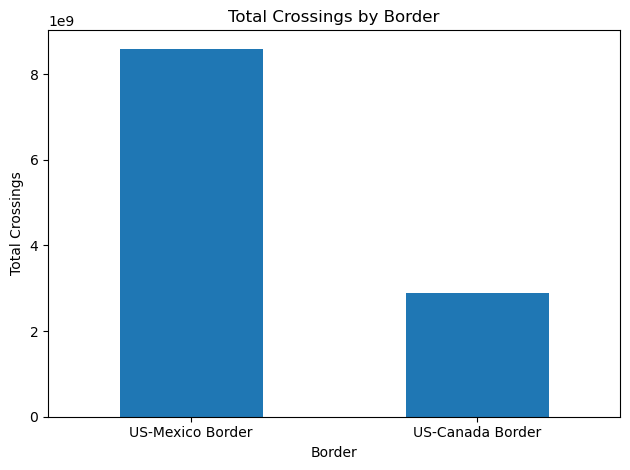

In [ ]:
import matplotlib.pyplot as plt

pdf = border_analysis.toPandas()

pdf.plot(kind="bar", x="Border", y="Total_Crossings", legend=False)

plt.title("Total Crossings by Border")
plt.xlabel("Border")
plt.ylabel("Total Crossings")

plt.xticks(rotation=0)   # rotae x-axis labels 90 for better readability

plt.tight_layout()
plt.show()

### 5.2 Total Crossings by Measure

This analysis identifies which transportation measures (e.g., vehicles, pedestrians, trucks) contribute the most to total crossings.

In [ ]:
measure_analysis = df.groupBy("Measure") \
    .agg(sum("Value").alias("Total_Crossings")) \
    .orderBy("Total_Crossings", ascending=False)

measure_analysis.show()

+--------------------+---------------+
|             Measure|Total_Crossings|
+--------------------+---------------+
|Personal Vehicle ...|     6506215972|
|   Personal Vehicles|     3148059957|
|         Pedestrians|     1303898913|
|              Trucks|      340546108|
|      Bus Passengers|      160027594|
|               Buses|        9545006|
|    Train Passengers|        7529303|
|              Trains|        1120396|
+--------------------+---------------+



### 5.3 Total Crossings by Year

This analysis examines how total crossings change over time, revealing long-term trends and potential external impacts.

In [ ]:
from pyspark.sql.functions import to_date, year

df = df.withColumn("Date_parsed", to_date("Date", "MMM yyyy"))
df = df.withColumn("Year", year("Date_parsed"))

df.select("Date", "Date_parsed", "Year").show(5, False)

+--------+-----------+----+
|Date    |Date_parsed|Year|
+--------+-----------+----+
|Jan 2026|2026-01-01 |2026|
|Jan 2026|2026-01-01 |2026|
|Dec 2025|2025-12-01 |2025|
|Nov 2025|2025-11-01 |2025|
|Jul 2025|2025-07-01 |2025|
+--------+-----------+----+
only showing top 5 rows


In [ ]:
from pyspark.sql.functions import to_date, year, sum

# Extract year from Date column
df = df.withColumn("Date_parsed", to_date("Date", "MMM yyyy"))
df = df.withColumn("Year", year("Date_parsed"))

# Total crossings by year
year_analysis = df.groupBy("Year") \
    .agg(sum("Value").alias("Total_Crossings")) \
    .orderBy("Year")

year_analysis.show()

+----+---------------+
|Year|Total_Crossings|
+----+---------------+
|1996|      424326538|
|1997|      487571047|
|1998|      498367381|
|1999|      526057768|
|2000|      527422164|
|2001|      479842216|
|2002|      462021027|
|2003|      443017400|
|2004|      444305796|
|2005|      436112146|
|2006|      426158914|
|2007|      403615100|
|2008|      386600603|
|2009|      348090864|
|2010|      331717926|
|2011|      319518381|
|2012|      331070167|
|2013|      342606811|
|2014|      349085046|
|2015|      350542766|
+----+---------------+
only showing top 20 rows


In [ ]:
spark.sql("""
SELECT YEAR(to_date(Date, 'MMM yyyy')) AS Year,
       SUM(Value) AS Total_Crossings
FROM crossings
GROUP BY YEAR(to_date(Date, 'MMM yyyy'))
ORDER BY Year
""").show()

+----+---------------+
|Year|Total_Crossings|
+----+---------------+
|1996|      424326538|
|1997|      487571047|
|1998|      498367381|
|1999|      526057768|
|2000|      527422164|
|2001|      479842216|
|2002|      462021027|
|2003|      443017400|
|2004|      444305796|
|2005|      436112146|
|2006|      426158914|
|2007|      403615100|
|2008|      386600603|
|2009|      348090864|
|2010|      331717926|
|2011|      319518381|
|2012|      331070167|
|2013|      342606811|
|2014|      349085046|
|2015|      350542766|
+----+---------------+
only showing top 20 rows


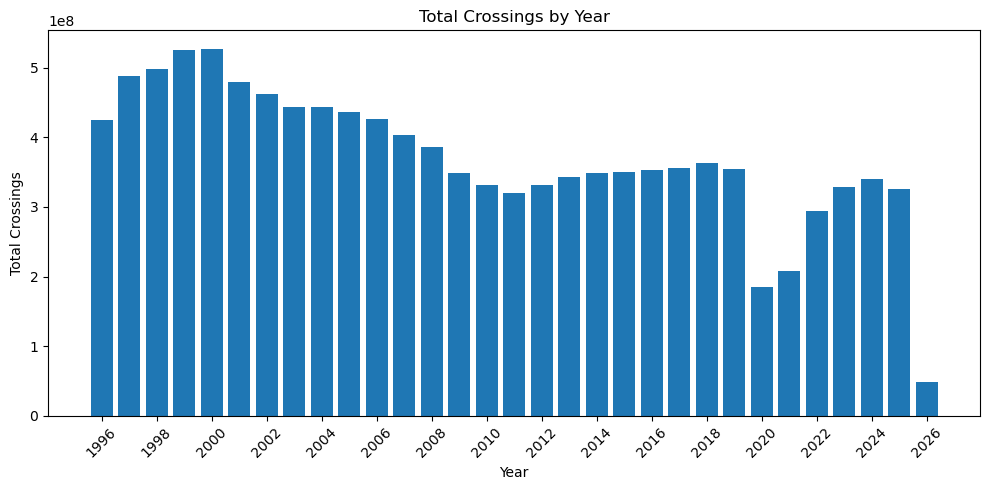

In [ ]:
import matplotlib.pyplot as plt

pdf = year_analysis.toPandas()

plt.figure(figsize=(10,5))  

plt.bar(pdf["Year"], pdf["Total_Crossings"])

plt.title("Total Crossings by Year")
plt.xlabel("Year")
plt.ylabel("Total Crossings")

plt.xticks(pdf["Year"][::2], rotation=45) 

plt.tight_layout()
plt.show()

### 5.4 Top Ports by Total Crossings

This analysis identifies the busiest border ports based on total crossing volume.

In [ ]:
port_analysis = df.groupBy("Port Name") \
    .agg(sum("Value").alias("Total_Crossings")) \
    .orderBy("Total_Crossings", ascending=False)

port_analysis.show(10)

+--------------------+---------------+
|           Port Name|Total_Crossings|
+--------------------+---------------+
|          San Ysidro|     1449798032|
|             El Paso|     1308744295|
|              Laredo|      741498521|
|             Hidalgo|      660325848|
|            Calexico|      630228448|
|         Brownsville|      612299728|
|Buffalo Niagara F...|      592241423|
|           Otay Mesa|      562269475|
|             Detroit|      506840195|
|             Nogales|      481449582|
+--------------------+---------------+
only showing top 10 rows


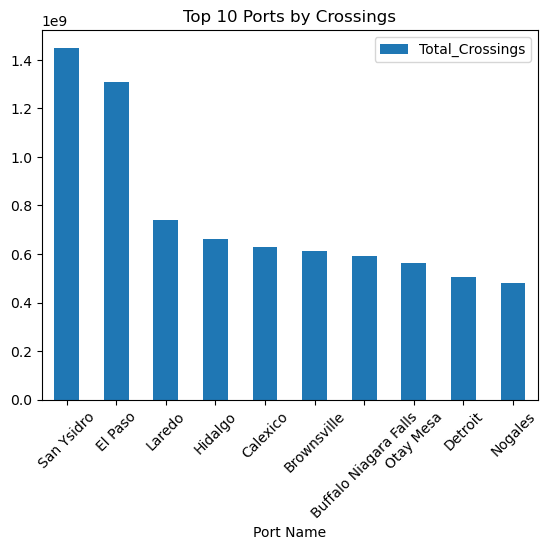

In [ ]:
pdf = port_analysis.limit(10).toPandas()

pdf.plot(kind="bar", x="Port Name", y="Total_Crossings")
plt.title("Top 10 Ports by Crossings")
plt.xticks(rotation=45)
plt.show()

## 6. Equivalent Analysis with Spark SQL

This section demonstrates the use of Spark SQL to perform equivalent analyses, highlighting the flexibility of Spark’s unified processing engine.

#### Step 1: Register DataFrame as SQL View

The cleaned dataset is registered as a temporary view named "border_data". 
This enables the use of Spark SQL for querying and analysis.


In [ ]:
df_clean.createOrReplaceTempView("border_data")

### 6.1 Total Crossings by Border
This query calculates total border crossings for each border.

The results show that the U.S.-Mexico border generally has higher traffic than the U.S.-Canada border, indicating stronger movement of people and goods.

In [ ]:
result_border = spark.sql("""
SELECT Border, SUM(Value) AS Total
FROM border_data
GROUP BY Border
""")

result_border.show()

+----------------+----------+
|          Border|     Total|
+----------------+----------+
|US-Mexico Border|8596716289|
|US-Canada Border|2880226960|
+----------------+----------+



### 6.2 Total Crossings by Measure
This analysis shows the contribution of different transportation measures.

Personal vehicles and trucks contribute the most, highlighting their importance in cross-border transportation.

In [ ]:
result_measure = spark.sql("""
SELECT Measure, SUM(Value) AS Total
FROM border_data
GROUP BY Measure
ORDER BY Total DESC
""")

result_measure.show()

+--------------------+----------+
|             Measure|     Total|
+--------------------+----------+
|Personal Vehicle ...|6506215972|
|   Personal Vehicles|3148059957|
|         Pedestrians|1303898913|
|              Trucks| 340546108|
|      Bus Passengers| 160027594|
|               Buses|   9545006|
|    Train Passengers|   7529303|
|              Trains|   1120396|
+--------------------+----------+



### 6.3 Total Crossings by Year
This analysis shows the trend of total border crossings over time.

Crossings increased in the late 1990s, declined after 2000, and gradually recovered after 2012.

In [ ]:
result_year = spark.sql("""
SELECT Year, SUM(Value) AS Total
FROM border_data
GROUP BY Year
ORDER BY Year
""")

result_year.show()

+----+---------+
|Year|    Total|
+----+---------+
|1996|424326538|
|1997|487571047|
|1998|498367381|
|1999|526057768|
|2000|527422164|
|2001|479842216|
|2002|462021027|
|2003|443017400|
|2004|444305796|
|2005|436112146|
|2006|426158914|
|2007|403615100|
|2008|386600603|
|2009|348090864|
|2010|331717926|
|2011|319518381|
|2012|331070167|
|2013|342606811|
|2014|349085046|
|2015|350542766|
+----+---------+
only showing top 20 rows


### 6.4 Top Ports by Total Crossings
This analysis identifies the busiest ports.

San Ysidro and El Paso have the highest crossing volumes.

In [ ]:
result_ports = spark.sql("""
SELECT `Port Name`, SUM(Value) AS Total
FROM border_data
GROUP BY `Port Name`
ORDER BY Total DESC
LIMIT 10
""")

result_ports.show()

+--------------------+----------+
|           Port Name|     Total|
+--------------------+----------+
|          San Ysidro|1449798032|
|             El Paso|1308744295|
|              Laredo| 741498521|
|             Hidalgo| 660325848|
|            Calexico| 630228448|
|         Brownsville| 612299728|
|Buffalo Niagara F...| 592241423|
|           Otay Mesa| 562269475|
|             Detroit| 506840195|
|             Nogales| 481449582|
+--------------------+----------+



## 7. MongoDB Aggregation Queries

In this section, we perform similar aggregations using MongoDB’s aggregation framework to compare with Spark-based processing.

### 7.1 Total Crossings by Border
This aggregation calculates total crossings for each border.

The U.S.-Mexico border shows significantly higher traffic than the U.S.-Canada border.

In [ ]:
pipeline = [
    {
        "$group": {
            "_id": "$Border",
            "total": {"$sum": "$Value"}
        }
    },
    {
        "$sort": {"total": -1}
    }
]

result_7_1 = list(collection.aggregate(pipeline))
result_7_1

[{'_id': 'US-Mexico Border', 'total': 8596716289},
 {'_id': 'US-Canada Border', 'total': 2880226960}]

### 7.2 Total Crossings by Measure
This analysis shows the contribution of different transportation measures.

Personal vehicles and trucks contribute the most to total crossings.

In [ ]:
pipeline = [
    {
        "$group": {
            "_id": "$Measure",
            "total": {"$sum": "$Value"}
        }
    },
    {
        "$sort": {"total": -1}
    }
]

result_7_2 = list(collection.aggregate(pipeline))
result_7_2

[{'_id': 'Personal Vehicle Passengers', 'total': 6506215972},
 {'_id': 'Personal Vehicles', 'total': 3148059957},
 {'_id': 'Pedestrians', 'total': 1303898913},
 {'_id': 'Trucks', 'total': 340546108},
 {'_id': 'Bus Passengers', 'total': 160027594},
 {'_id': 'Buses', 'total': 9545006},
 {'_id': 'Train Passengers', 'total': 7529303},
 {'_id': 'Trains', 'total': 1120396}]

### 7.3 Total Crossings by Year
This aggregation analyzes border crossings over time.

A significant drop can be observed around 2020 due to COVID-19, followed by recovery.

In [ ]:
pipeline = [
    {
        "$addFields": {
            "Year": {
                "$toInt": {"$substr": ["$Date", 4, 4]}
            }
        }
    },
    {
        "$group": {
            "_id": "$Year",
            "total": {"$sum": "$Value"}
        }
    },
    {
        "$sort": {"_id": 1}
    }
]

result_7_3 = list(collection.aggregate(pipeline))
result_7_3

[{'_id': 1996, 'total': 424326538},
 {'_id': 1997, 'total': 487571047},
 {'_id': 1998, 'total': 498367381},
 {'_id': 1999, 'total': 526057768},
 {'_id': 2000, 'total': 527422164},
 {'_id': 2001, 'total': 479842216},
 {'_id': 2002, 'total': 462021027},
 {'_id': 2003, 'total': 443017400},
 {'_id': 2004, 'total': 444305796},
 {'_id': 2005, 'total': 436112146},
 {'_id': 2006, 'total': 426158914},
 {'_id': 2007, 'total': 403615100},
 {'_id': 2008, 'total': 386600603},
 {'_id': 2009, 'total': 348090864},
 {'_id': 2010, 'total': 331717926},
 {'_id': 2011, 'total': 319518381},
 {'_id': 2012, 'total': 331070167},
 {'_id': 2013, 'total': 342606811},
 {'_id': 2014, 'total': 349085046},
 {'_id': 2015, 'total': 350542766},
 {'_id': 2016, 'total': 352587832},
 {'_id': 2017, 'total': 356675656},
 {'_id': 2018, 'total': 363185285},
 {'_id': 2019, 'total': 354128366},
 {'_id': 2020, 'total': 185454385},
 {'_id': 2021, 'total': 208001496},
 {'_id': 2022, 'total': 294204095},
 {'_id': 2023, 'total': 3286

7.4 Top Ports by Total Crossings
This query identifies the busiest ports.

Ports such as Laredo and Hidalgo rank among the top.

In [ ]:
pipeline = [
    {
        "$group": {
            "_id": "$Port Name",
            "total": {"$sum": "$Value"}
        }
    },
    {
        "$sort": {"total": -1}
    },
    {
        "$limit": 10
    }
]

result_7_4 = list(collection.aggregate(pipeline))
result_7_4

[{'_id': 'San Ysidro', 'total': 1449798032},
 {'_id': 'El Paso', 'total': 1308744295},
 {'_id': 'Laredo', 'total': 741498521},
 {'_id': 'Hidalgo', 'total': 660325848},
 {'_id': 'Calexico', 'total': 630228448},
 {'_id': 'Brownsville', 'total': 612299728},
 {'_id': 'Buffalo Niagara Falls', 'total': 592241423},
 {'_id': 'Otay Mesa', 'total': 562269475},
 {'_id': 'Detroit', 'total': 506840195},
 {'_id': 'Nogales', 'total': 481449582}]

## 8. Performance Comparison and Optimization

This section evaluates query performance across different approaches, including PySpark DataFrame API, Spark SQL, and MongoDB aggregation.

We also demonstrate optimization techniques such as:
- Spark caching
- Query execution plan analysis
- MongoDB indexing

### 8.1 Performance Comparison

### 8.2 Spark Optimization

### 8.3 MongoDB Optimization

## 9. Advanced Meaningful Analyses

Each member is responsible for one analysis question.

For each subsection:
- Clearly answer the question
- Include at least one visualization
- Provide a short interpretation of the results
- Write the final dataset back to MongoDB

You are encouraged to explore beyond the minimum requirements if you find interesting patterns.

### 9.1 Long-term Changes in Border Crossing Structure

Question:
How have transportation patterns evolved over time at the U.S.-Canada and U.S.-Mexico borders?

### 9.2 Peak Month and Peak Volume for Top Ports

Question:
For the top ports at each border, which month has the highest crossing volume?

(Hint: identify both the peak month and the corresponding volume, and compare patterns across ports.)

### 9.3 Impact of External Events (COVID-19)

Question:
How did COVID-19 affect border crossing volumes over time?

(Hint: compare trends before, during, and after the pandemic, and look for disruptions and recovery patterns.)

In [ ]:
from pyspark.sql.functions import when, col

df = df.withColumn(
    "Period",
    when(col("Year") < 2020, "Before COVID")
    .when((col("Year") >= 2020) & (col("Year") <= 2021), "During COVID")
    .otherwise("After COVID")
)

In [ ]:
from pyspark.sql.functions import sum

covid_analysis = df.groupBy("Period") \
    .agg(sum("Value").alias("Total_Crossings")) \
    .orderBy("Period")

covid_analysis.show()

+------------+---------------+
|      Period|Total_Crossings|
+------------+---------------+
| After COVID|     1338860168|
|Before COVID|     9744627200|
|During COVID|      393455881|
+------------+---------------+



In [ ]:
spark.sql("""
SELECT
  CASE
    WHEN YEAR(to_date(Date, 'MMM yyyy')) < 2020 THEN 'Before COVID'
    WHEN YEAR(to_date(Date, 'MMM yyyy')) BETWEEN 2020 AND 2021 THEN 'During COVID'
    ELSE 'After COVID'
  END AS Period,
  SUM(Value) AS Total_Crossings
FROM crossings
GROUP BY
  CASE
    WHEN YEAR(to_date(Date, 'MMM yyyy')) < 2020 THEN 'Before COVID'
    WHEN YEAR(to_date(Date, 'MMM yyyy')) BETWEEN 2020 AND 2021 THEN 'During COVID'
    ELSE 'After COVID'
  END
ORDER BY Period
""").show()

+------------+---------------+
|      Period|Total_Crossings|
+------------+---------------+
| After COVID|     1338860168|
|Before COVID|     9744627200|
|During COVID|      393455881|
+------------+---------------+



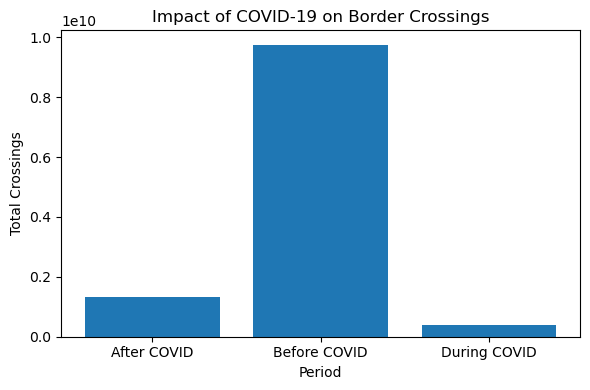

In [ ]:
import matplotlib.pyplot as plt

pdf = covid_analysis.toPandas()

plt.figure(figsize=(6,4))
plt.bar(pdf["Period"], pdf["Total_Crossings"])

plt.title("Impact of COVID-19 on Border Crossings")
plt.xlabel("Period")
plt.ylabel("Total Crossings")

plt.tight_layout()
plt.show()

### 9.4 Port Growth & Decline Analysis

Question:
Which ports have experienced the most significant growth or decline over time?

(Hint: compare two time points and consider both absolute and relative changes.)

#### Step 1：Choose 2019 vs 2024
This pipeline extracts yearly data and compares port activity between two selected years.

In [ ]:
pipeline = [
    {
        "$addFields": {
            "Year": {
                "$toInt": {"$substr": ["$Date", 4, 4]}
            }
        }
    },
    {
        "$match": {
            "Year": {"$in": [2019, 2024]}
        }
    },
    {
        "$group": {
            "_id": {
                "Port": "$Port Name",
                "Year": "$Year"
            },
            "total": {"$sum": "$Value"}
        }
    }
]

data = list(collection.aggregate(pipeline))

#### Step 2：Convert to Pandas DataFrame
The data is converted to a Pandas DataFrame for further analysis.

In [ ]:
import pandas as pd  

df_growth = pd.DataFrame(data)  

# Extract fields from nested structure
df_growth["Port"] = df_growth["_id"].apply(lambda x: x["Port"])  
df_growth["Year"] = df_growth["_id"].apply(lambda x: x["Year"])  

# Pivot table for comparison
df_pivot = df_growth.pivot(index="Port", columns="Year", values="total").fillna(0)  

# Calculate change between years
df_pivot["Change"] = df_pivot[2024] - df_pivot[2019]  

# Sort by change
df_sorted = df_pivot.sort_values("Change", ascending=False)  

df_sorted.head(10)

Year,2019,2024,Change
Port,,,
Ysleta,0.0,12100990.0,12100990.0
Hidalgo,15553020.0,18134636.0,2581616.0
San Luis,10469779.0,11570188.0,1100409.0
Tornillo,1361577.0,2317675.0,956098.0
Nogales,14125594.0,15007703.0,882109.0
Cross Border Xpress,1620661.0,2175047.0,554386.0
Progreso,5174707.0,5688000.0,513293.0
Eagle Pass,9951845.0,10414971.0,463126.0
Santa Teresa,2304052.0,2730006.0,425954.0


### Top 10 Ports by Growth (2019–2024)

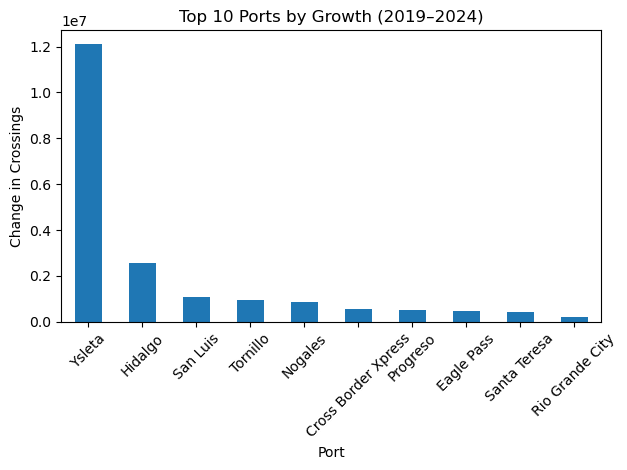

In [ ]:
import matplotlib.pyplot as plt

# Select top 10 growth ports
top_growth = df_sorted.head(10)

plt.figure()
top_growth["Change"].plot(kind="bar")

plt.title("Top 10 Ports by Growth (2019–2024)")
plt.xlabel("Port")
plt.ylabel("Change in Crossings")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

This chart shows the ports with the highest growth between 2019 and 2024.

### Top 10 Ports by Decline (2019–2024)

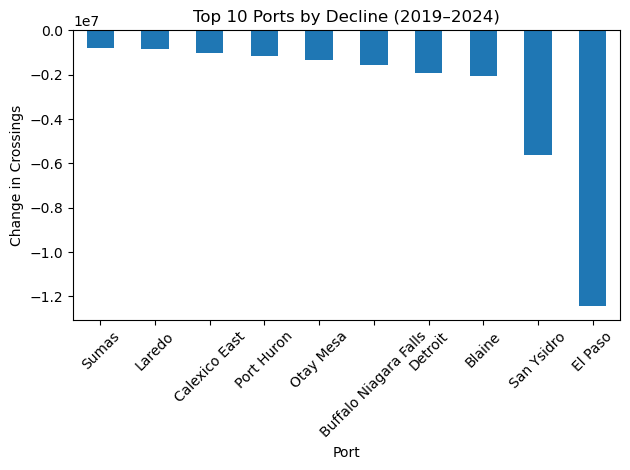

In [ ]:
bottom_ports = df_sorted.tail(10)

plt.figure()
bottom_ports["Change"].plot(kind="bar")

plt.title("Top 10 Ports by Decline (2019–2024)")
plt.xlabel("Port")
plt.ylabel("Change in Crossings")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The chart shows that some ports experienced significant growth, while others declined.

This reflects changes in cross-border traffic patterns over time.